In [ ]:
!pip install -q kaggle
!pip install -q torch torchvision scikit-learn
!pip install -q facenet-pytorch

In [ ]:
from google.colab import files
files.upload()  # Choose kaggle.json from your computer

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"aashikagupta1","key":"713646162a9cd12306b88ee84be39387"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d shuvoalok/ck-dataset
!unzip -q ck-dataset.zip -d ck_dataset

Dataset URL: https://www.kaggle.com/datasets/shuvoalok/ck-dataset
License(s): other
ck-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace ck_dataset/anger/S010_004_00000017.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
import os
import random
from PIL import Image
from torch.utils.data import Dataset

class CKPlusPairsDataset(Dataset):
    def __init__(self, root, transform=None, max_pairs_per_class=1000):
        self.transform = transform
        self.data = []

        expression_dirs = sorted(os.listdir(root))  # Each folder is an expression class
        for expression in expression_dirs:
            class_path = os.path.join(root, expression)
            image_files = sorted(os.listdir(class_path))

            if len(image_files) < 2:
                continue

            # Randomly sample pairs from this expression class
            sampled_pairs = 0
            while sampled_pairs < max_pairs_per_class:
                img1, img2 = random.sample(image_files, 2)
                if img1 != img2:
                    img_path1 = os.path.join(class_path, img1)
                    img_path2 = os.path.join(class_path, img2)
                    self.data.append((img_path1, img_path2))
                    sampled_pairs += 1

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path1, img_path2 = self.data[idx]
        img1 = Image.open(img_path1).convert("L")
        img2 = Image.open(img_path2).convert("L")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2

In [ ]:
import os

# List folder contents
os.listdir("ck_dataset")

['disgust', 'sadness', 'contempt', 'anger', 'fear', 'surprise', 'happy']

In [ ]:
!pip uninstall -y pillow
!pip install pillow==10.2.0

Found existing installation: pillow 10.2.0
Uninstalling pillow-10.2.0:
  Successfully uninstalled pillow-10.2.0
  Using cached pillow-10.2.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
Using cached pillow-10.2.0-cp311-cp311-manylinux_2_28_x86_64.whl (4.5 MB)


Total pairs: 7000
Image shape: torch.Size([1, 64, 64])


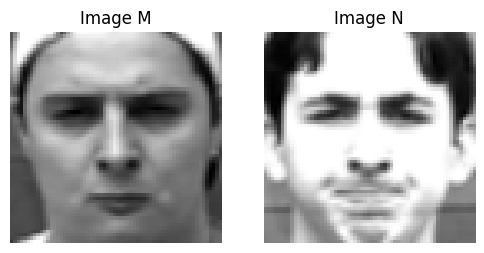

In [ ]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Define basic image transform
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),  # Converts to [0,1] and channels first (C, H, W)
])

# ✅ Corrected dataset path
dataset_path = "ck_dataset"
dataset = CKPlusPairsDataset(root=dataset_path, transform=transform)

# Preview size and shape
print("Total pairs:", len(dataset))
img1, img2 = dataset[0]
print("Image shape:", img1.shape)

# Plot the pair
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(img1.squeeze(), cmap="gray")
plt.title("Image M")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2.squeeze(), cmap="gray")
plt.title("Image N")
plt.axis("off")

plt.show()

In [ ]:
img_path1, img_path2 = dataset.data[0]
print("File 1:", img_path1)
print("File 2:", img_path2)

File 1: ck_dataset/anger/S045_005_00000029.png
File 2: ck_dataset/anger/S037_003_00000022.png


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class ExpressionEncoder(nn.Module):
    def __init__(self, latent_dim=128):
        super(ExpressionEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 64x64 → 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 32x32 → 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 16x16 → 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 8x8 → 4x4
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        self.fc = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):
        batch_size = x.size(0)
        x = self.encoder(x)
        x = x.view(batch_size, -1)
        x = self.fc(x)
        x = F.normalize(x, dim=1)  # Normalize for stability in MI estimation
        return x

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
class GlobalStatisticsNetwork(nn.Module):
    def __init__(self, latent_dim=128, hidden_dim=256):
        super(GlobalStatisticsNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, e1, e2):
        # Concatenate expression embeddings
        h = torch.cat([e1, e2], dim=1)
        return self.net(h)

In [ ]:
def mi_dv_loss(U, e_m, e_n):
    """
    DV Mutual Information loss with stabilization
    """
    pos = U(e_m, e_n)
    e_n_shuffled = e_n[torch.randperm(e_n.size(0))]
    neg = U(e_m, e_n_shuffled)

    # Log-sum-exp trick for stability
    logsumexp = torch.logsumexp(neg, dim=0) - torch.log(torch.tensor(neg.size(0), dtype=torch.float, device=neg.device))

    # Mutual Information estimate
    mi = torch.mean(pos) - logsumexp
    return -mi

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model init
encoder_exp = ExpressionEncoder(latent_dim=128).to(device)
stats_net = GlobalStatisticsNetwork(latent_dim=128).to(device)

# Optimizer
optimizer = optim.Adam(list(encoder_exp.parameters()) + list(stats_net.parameters()), lr=1e-3)

# DataLoader
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Training loop (few epochs only for demo)
for epoch in range(15):
    total_loss = 0.0
    for batch in loader:
        img_m, img_n = batch
        img_m, img_n = img_m.to(device), img_n.to(device)

        e_m = encoder_exp(img_m)
        e_n = encoder_exp(img_n)

        loss = mi_dv_loss(stats_net, e_m, e_n)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: MI Loss = {total_loss / len(loader):.4f}")

Epoch 1: MI Loss = -0.0535
Epoch 2: MI Loss = -0.6925
Epoch 3: MI Loss = -1.1634
Epoch 4: MI Loss = -1.3909
Epoch 5: MI Loss = -1.5445
Epoch 6: MI Loss = -1.5620
Epoch 7: MI Loss = -1.7111
Epoch 8: MI Loss = -1.7364
Epoch 9: MI Loss = -1.7234
Epoch 10: MI Loss = -1.7243
Epoch 11: MI Loss = -1.7890
Epoch 12: MI Loss = -1.8003
Epoch 13: MI Loss = -1.7879
Epoch 14: MI Loss = -1.8220
Epoch 15: MI Loss = -1.7555


In [ ]:
class IdentityEncoder(nn.Module):
    def __init__(self, latent_dim=128):
        super(IdentityEncoder, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),  # 48x48 -> 24x24
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 24x24 -> 12x12
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # 12x12 -> 6x6
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(128, latent_dim)

    def forward(self, x):
        x = self.cnn(x)
        x = x.view(x.size(0), -1)
        x = F.normalize(self.fc(x), dim=1)
        return x

# Separate statistics network for identity-expression MI
class AdversarialStatisticsNetwork(nn.Module):
    def __init__(self, latent_dim=128, hidden_dim=256):
        super(AdversarialStatisticsNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, id_feat, exp_feat):
        h = torch.cat([id_feat, exp_feat], dim=1)
        return self.net(h)

In [ ]:
def adversarial_mi_loss(U_adv, id_feat, exp_feat):
    """
    U_adv: statistics network trying to detect MI between identity & expression
    id_feat: identity representation
    exp_feat: expression representation (frozen)
    """
    # Positive pair (id, exp)
    pos = U_adv(id_feat, exp_feat)

    # Negative pair (id, shuffled exp)
    exp_shuffled = exp_feat[torch.randperm(exp_feat.size(0))]
    neg = U_adv(id_feat, exp_shuffled)

    # Log-sum-exp trick for stability
    logsumexp = torch.logsumexp(neg, dim=0) - torch.log(torch.tensor(neg.size(0), dtype=torch.float, device=neg.device))

    mi = torch.mean(pos) - logsumexp
    return mi  # No negative sign — because we alternate maximization & minimization

In [ ]:
# Models
encoder_id = IdentityEncoder(latent_dim=128).to(device)
adv_stats_net = AdversarialStatisticsNetwork(latent_dim=128).to(device)

# Optimizers
optimizer_id = optim.Adam(encoder_id.parameters(), lr=1e-3)
optimizer_adv = optim.Adam(adv_stats_net.parameters(), lr=1e-3)

# Freeze expression encoder (Stage 1 is done)
encoder_exp.eval()

# Adversarial training loop
for epoch in range(10):
    total_adv_loss = 0.0
    total_id_loss = 0.0

    for img_m, img_n in loader:
        img_m, img_n = img_m.to(device), img_n.to(device)

        # Forward
        with torch.no_grad():
            exp_feat = encoder_exp(img_m)

        id_feat = encoder_id(img_m)

        # === 1. Train Stats Network (maximize MI) ===
        mi = adversarial_mi_loss(adv_stats_net, id_feat.detach(), exp_feat.detach())  # fixed features
        loss_adv = -mi  # maximize MI
        optimizer_adv.zero_grad()
        loss_adv.backward()
        optimizer_adv.step()

        # === 2. Train Identity Encoder (minimize MI) ===
        mi = adversarial_mi_loss(adv_stats_net, id_feat, exp_feat.detach())  # update encoder_id
        loss_id = mi  # minimize MI
        optimizer_id.zero_grad()
        loss_id.backward()
        optimizer_id.step()

        total_adv_loss += loss_adv.item()
        total_id_loss += loss_id.item()

    print(f"Epoch {epoch+1} | Stats Loss: {total_adv_loss / len(loader):.4f} | Identity Loss: {total_id_loss / len(loader):.4f}")

Epoch 1 | Stats Loss: 0.0001 | Identity Loss: -0.0001
Epoch 2 | Stats Loss: 0.0000 | Identity Loss: -0.0000
Epoch 3 | Stats Loss: 0.0000 | Identity Loss: -0.0000
Epoch 4 | Stats Loss: 0.0000 | Identity Loss: -0.0000
Epoch 5 | Stats Loss: -0.0000 | Identity Loss: 0.0000
Epoch 6 | Stats Loss: 0.0000 | Identity Loss: -0.0000
Epoch 7 | Stats Loss: -0.0000 | Identity Loss: 0.0000
Epoch 8 | Stats Loss: 0.0000 | Identity Loss: -0.0000
Epoch 9 | Stats Loss: 0.0000 | Identity Loss: -0.0000
Epoch 10 | Stats Loss: -0.0000 | Identity Loss: 0.0000


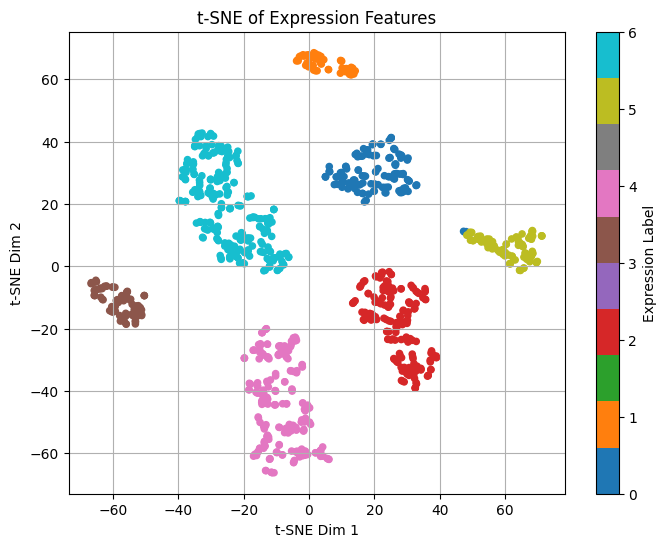

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# For this, we need a loader that includes expression labels (folder names)
class CKPlusLabeledDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples = []
        self.labels = []
        self.transform = transform
        self.label_map = {}  # map string expression to int

        expressions = sorted(os.listdir(root))
        for idx, expr in enumerate(expressions):
            self.label_map[expr] = idx
            expr_folder = os.path.join(root, expr)
            for fname in os.listdir(expr_folder):
                if fname.endswith('.png'):
                    self.samples.append(os.path.join(expr_folder, fname))
                    self.labels.append(idx)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image = Image.open(self.samples[idx]).convert("L")
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# Reload dataset with labels
labeled_dataset = CKPlusLabeledDataset(root="ck_dataset", transform=transform)
labeled_loader = DataLoader(labeled_dataset, batch_size=32, shuffle=False)

# Encode expression features
expression_features = []
expression_labels = []

with torch.no_grad():
    for imgs, labels in labeled_loader:
        imgs = imgs.to(device)
        feats = encoder_exp(imgs).cpu().numpy()
        expression_features.append(feats)
        expression_labels.extend(labels.numpy())

expression_features = np.vstack(expression_features)

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=15, random_state=0)
tsne_proj = tsne.fit_transform(expression_features)

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(tsne_proj[:,0], tsne_proj[:,1], c=expression_labels, cmap='tab10', s=20)
plt.title("t-SNE of Expression Features")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.colorbar(scatter, label="Expression Label")
plt.grid(True)
plt.show()

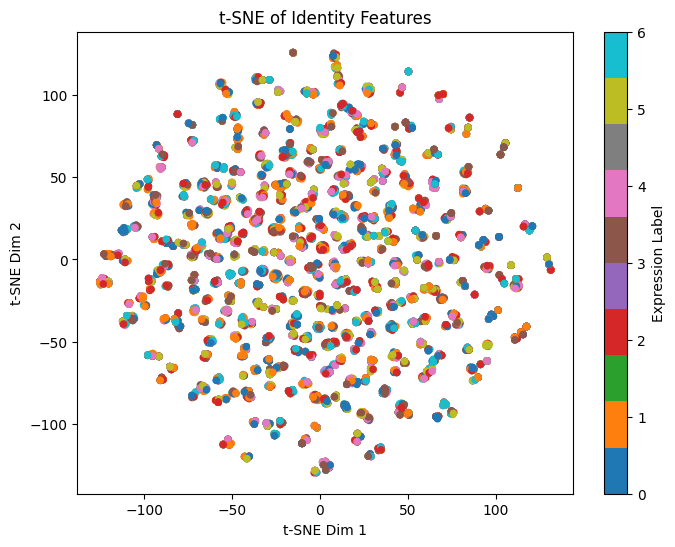

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Identity features and expression labels
identity_feats = []
expression_labels = []

for img_m, img_n in loader:
    img_m = img_m.to(device)
    with torch.no_grad():
        identity_feat = encoder_id(img_m).cpu().numpy()
    identity_feats.append(identity_feat)

    # Dummy expression label just for coloring (modify if real labels available)
    batch_size = img_m.shape[0]
    expression_labels.extend([i % 7 for i in range(batch_size)])  # simulate 7 classes

identity_feats = np.vstack(identity_feats)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_id = tsne.fit_transform(identity_feats)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_id[:, 0], tsne_id[:, 1], c=expression_labels, cmap='tab10', s=20)
plt.title("t-SNE of Identity Features")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.colorbar(scatter, label="Expression Label")
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image
import random

# Sample 50 random images from labeled dataset
sample_size = 50
sample_indices = random.sample(range(len(labeled_dataset)), sample_size)

images = []
expressions = []
with torch.no_grad():
    for idx in sample_indices:
        img, label = labeled_dataset[idx]
        images.append(img)
        expressions.append(label)

images_tensor = torch.stack(images).to(device)
expression_embeddings = encoder_exp(images_tensor).cpu()

In [ ]:
import torch.nn.functional as F

# Normalize embeddings for cosine similarity
normalized_embeddings = F.normalize(expression_embeddings, dim=1)

# Compute pairwise cosine similarity
cos_sim = torch.matmul(normalized_embeddings, normalized_embeddings.T)

# For distances: 1 - sim
cos_dist = 1 - cos_sim

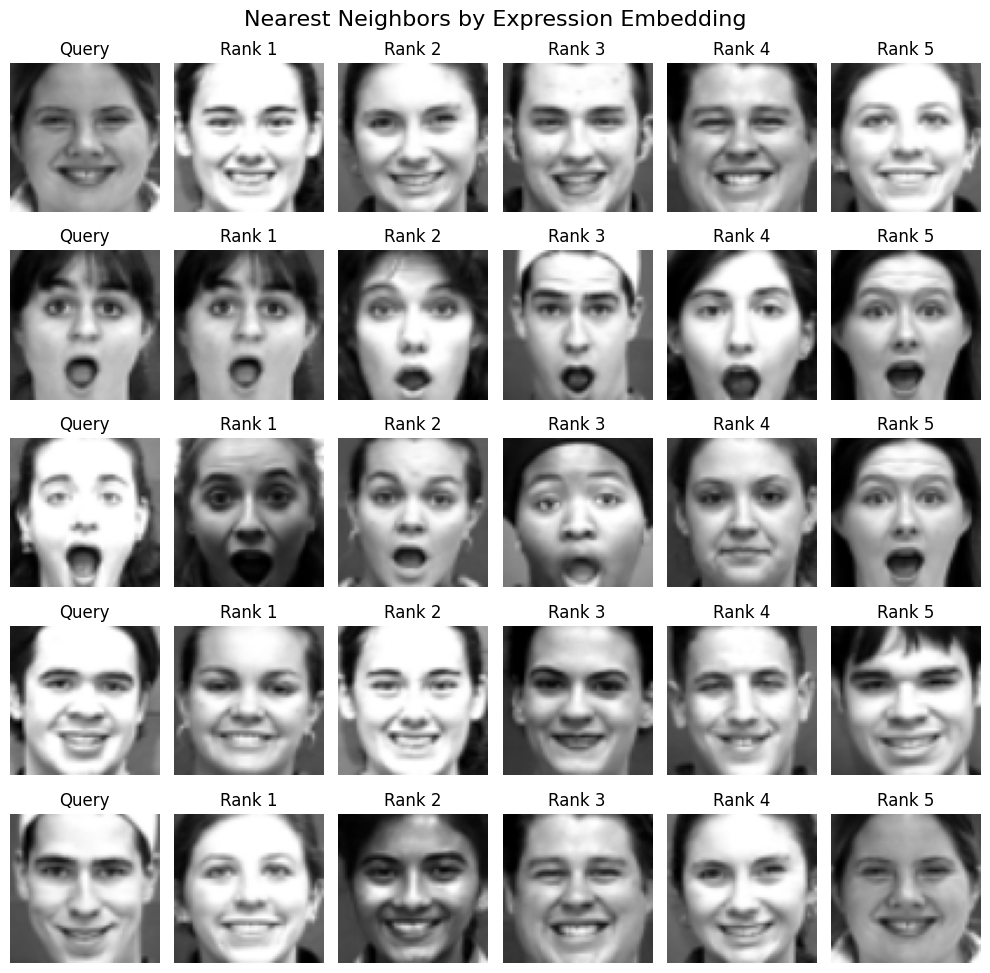

In [ ]:
def plot_nearest_neighbors(images, distances, k=5):
    num_queries = 5  # Show for first 5 queries
    fig, axes = plt.subplots(num_queries, k + 1, figsize=(k * 2, num_queries * 2))
    fig.suptitle("Nearest Neighbors by Expression Embedding", fontsize=16)

    for i in range(num_queries):
        # Show query
        query_img = to_pil_image(images[i].cpu())
        axes[i][0].imshow(query_img, cmap='gray')
        axes[i][0].set_title("Query")
        axes[i][0].axis("off")

        # Get k nearest (excluding self)
        nearest_indices = distances[i].argsort()[1:k + 1]  # skip self (0th)
        for j, idx in enumerate(nearest_indices):
            neighbor_img = to_pil_image(images[idx].cpu())
            axes[i][j + 1].imshow(neighbor_img, cmap='gray')
            axes[i][j + 1].set_title(f"Rank {j+1}")
            axes[i][j + 1].axis("off")

    plt.tight_layout()
    plt.show()

# Plot
plot_nearest_neighbors(images_tensor.cpu(), cos_dist)

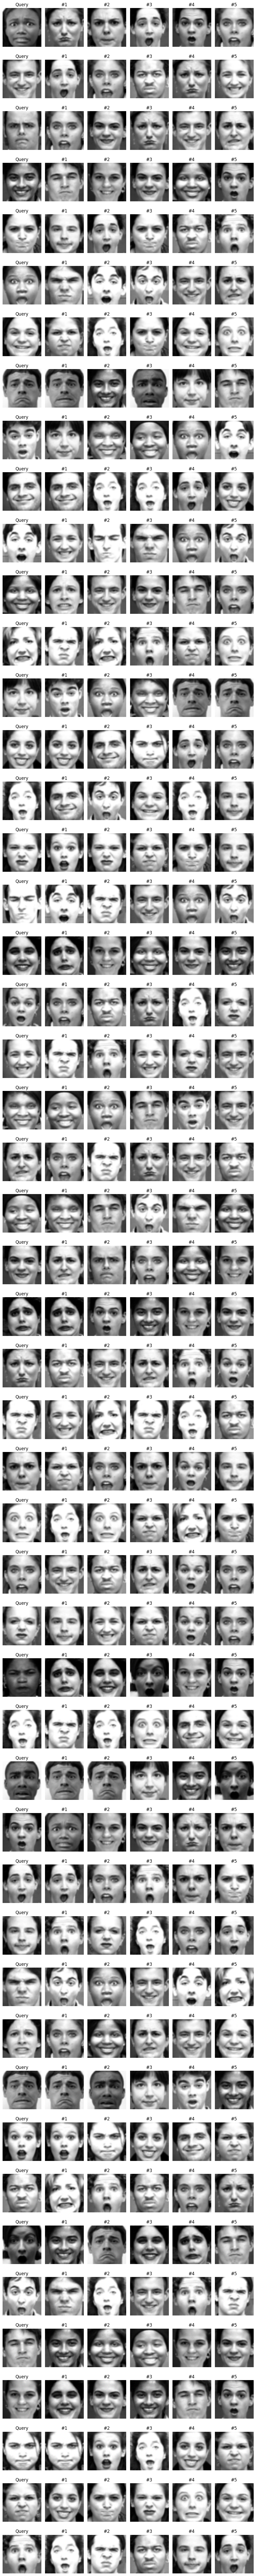

In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

# Sample images and compute identity embeddings
sample_size = 50
sample_indices = random.sample(range(len(labeled_dataset)), sample_size)
images = []
identity_embeddings = []

for idx in sample_indices:
    img, _ = labeled_dataset[idx]
    images.append(img)
    img_tensor = img.unsqueeze(0).to(device)
    with torch.no_grad():
        emb = encoder_id(img_tensor).cpu()
    identity_embeddings.append(emb)

# Stack into tensor
images_tensor = torch.stack(images)
identity_embeddings = torch.cat(identity_embeddings, dim=0)

# Compute cosine distance
normalized_embeddings = F.normalize(identity_embeddings, dim=1)
cos_sim = torch.matmul(normalized_embeddings, normalized_embeddings.T)
cos_dist = 1 - cos_sim

# Plot nearest neighbors
def plot_identity_neighbors(images, distances, k=5):
    fig, axes = plt.subplots(len(images), k + 1, figsize=(k * 2, len(images) * 2))
    for i in range(len(images)):
        query_img = images[i].squeeze()
        axes[i][0].imshow(query_img, cmap='gray')
        axes[i][0].set_title("Query")
        axes[i][0].axis('off')

        nearest = torch.argsort(distances[i])[1:k + 1]  # Skip self
        for j, idx in enumerate(nearest):
            neighbor_img = images[idx].squeeze()
            axes[i][j + 1].imshow(neighbor_img, cmap='gray')
            axes[i][j + 1].axis('off')
            axes[i][j + 1].set_title(f"#{j+1}")
    plt.tight_layout()
    plt.show()

plot_identity_neighbors(images_tensor, cos_dist)